# NovaCred Data Governance Task Force: Privacy & Compliance Analysis

## Table of Contents
1. [Library Overview](#library-overview)
2. [Data Loading and Preparation](#data-loading-and-preparation)
3. [PII Inventory: Direct Identifiers](#pii-inventory-direct-identifiers)
4. [PII Inventory: Quasi-Identifiers](#pii-inventory-quasi-identifiers)
5. [GDPR Compliance Gap Analysis](#gdpr-compliance-gap-analysis)
6. [EU AI Act Classification](#eu-ai-act-classification)

---

## Library Overview

**Libraries Used in This Analysis:**

| Library | Purpose |
|---------|---------|
| **pandas** | Data manipulation, analysis, and DataFrame operations |
| **numpy** | Numerical computations |
| **matplotlib** | Low-level visualization and plot creation |
| **seaborn** | Statistical data visualization with enhanced aesthetics |
| **json** | JSON file I/O for data loading |
| **datetime** | Timestamp generation for analysis logging |
| **warnings** | Control and filter warning messages |

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Utilities
import json
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"   Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
   Analysis Date: 2026-03-05 18:32:02


## Data Loading and Preparation

We load the cleaned credit application dataset produced by Notebook 1 (`data_cleaned.json`). All data quality issues identified in that notebook have already been resolved — this analysis therefore focuses exclusively on privacy and compliance dimensions.

In [2]:
# Load the cleaned data from JSON
with open('../data/data_cleaned.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f"✅ Loaded {len(raw_data)} credit applications from data_cleaned.json")

# Flatten nested JSON structure into a pandas DataFrame
# (same flatten logic as Notebook 2 for consistency)
def flatten_application(app):
    """
    Flatten nested JSON structure into a single-level dictionary.
    Retains all PII fields in their original form for the privacy audit.
    """
    flat = {
        # --- Direct Identifiers ---
        'applicant_id':      app.get('original_id'),
        'full_name':         app.get('applicant_info', {}).get('full_name'),
        'email':             app.get('applicant_info', {}).get('email'),
        'ssn':               app.get('applicant_info', {}).get('ssn'),
        'ip_address':        app.get('applicant_info', {}).get('ip_address'),
        'date_of_birth':     app.get('applicant_info', {}).get('date_of_birth'),

        # --- Quasi-Identifiers ---
        'gender':            app.get('applicant_info', {}).get('gender'),
        'zip_code':          app.get('applicant_info', {}).get('zip_code'),

        # --- Financial Information ---
        'annual_income':           app.get('financials', {}).get('annual_income'),
        'credit_history_months':   app.get('financials', {}).get('credit_history_months'),
        'debt_to_income':          app.get('financials', {}).get('debt_to_income'),
        'savings_balance':         app.get('financials', {}).get('savings_balance'),

        # --- Decision Information ---
        'loan_approved':    app.get('decision', {}).get('loan_approved'),
        'rejection_reason': app.get('decision', {}).get('rejection_reason'),

        # --- Governance Fields (expected but may be missing) ---
        'consent_timestamp':   app.get('consent_timestamp'),
        'retention_until':     app.get('retention_until'),
        'processing_purpose':  app.get('processing_purpose'),
        'data_source':         app.get('data_source'),
    }
    return flat

df = pd.DataFrame([flatten_application(app) for app in raw_data])

# Derive age from date_of_birth for quasi-identifier analysis
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365

print(f"\n📊 DataFrame Shape: {df.shape}")
print(f"   Rows: {df.shape[0]} applications")
print(f"   Columns: {df.shape[1]} features")
print(f"\n✅ Data successfully loaded and prepared for privacy analysis")
df.head(3)


✅ Loaded 496 credit applications from data_cleaned.json

📊 DataFrame Shape: (496, 19)
   Rows: 496 applications
   Columns: 19 features

✅ Data successfully loaded and prepared for privacy analysis


,applicant_id,full_name,email,ssn,ip_address,date_of_birth,gender,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,rejection_reason,consent_timestamp,retention_until,processing_purpose,data_source,age
0,app_200,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,2001-03-09,Male,10036,73000,23,0.20,31212,False,algorithm_risk_score,None,None,None,None,25
1,app_037,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,1992-03-31,Male,10032,78000,51,0.18,17915,False,algorithm_risk_score,None,None,None,None,33
2,app_215,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,1989-10-24,Male,10075,61000,41,0.21,37909,True,None,None,None,None,None,36


## PII Inventory: Direct Identifiers

### Overview
**GDPR Reference:** Art. 4(1) — Personal Data Definition | Art. 25 — Data Protection by Design  
**Issue:** Direct identifiers unambiguously identify a natural person on their own, without the need for cross-referencing additional fields.

### Description
This section catalogues all fields in the NovaCred dataset that qualify as **direct identifiers** under GDPR Art. 4(1). For each field we document: whether it is present and populated, the GDPR data category, the legal sensitivity level, and whether it is strictly necessary for the credit decision (Data Minimisation, Art. 5(1)(c)).

### Implementation

In [3]:
# ============================================================================
# DIRECT IDENTIFIER INVENTORY
# Check presence, completeness and data category for each direct PII field
# ============================================================================

direct_identifiers = {
    'full_name':     {'gdpr_category': 'Personal Data (Art. 4(1))',      'sensitivity': 'HIGH',     'necessary_for_decision': True},
    'email':         {'gdpr_category': 'Personal Data (Art. 4(1))',      'sensitivity': 'HIGH',     'necessary_for_decision': False},
    'ssn':           {'gdpr_category': 'National ID — High Risk',         'sensitivity': 'CRITICAL', 'necessary_for_decision': False},
    'ip_address':    {'gdpr_category': 'Personal Data (CJEU C-582/14)',   'sensitivity': 'MEDIUM',   'necessary_for_decision': False},
    'date_of_birth': {'gdpr_category': 'Personal Data (Art. 4(1))',      'sensitivity': 'HIGH',     'necessary_for_decision': True},
}

print('=' * 80)
print('DIRECT IDENTIFIER AUDIT')
print('=' * 80)

results = []

for field, meta in direct_identifiers.items():
    total       = len(df)
    present     = df[field].notna().sum()
    missing     = total - present
    pct_present = present / total * 100

    results.append({
        'Field':                    field,
        'GDPR Category':            meta['gdpr_category'],
        'Sensitivity':              meta['sensitivity'],
        'Necessary for Decision':   '✅ Yes' if meta['necessary_for_decision'] else '❌ No — remove',
        'Records Present':          present,
        'Records Missing':          missing,
        '% Present':                f'{pct_present:.1f}%',
    })

    flag = '🔴' if meta['sensitivity'] == 'CRITICAL' else ('🟠' if meta['sensitivity'] == 'HIGH' else '🟡')
    print(f'\n{flag} {field.upper()}')
    print(f"   GDPR Category  : {meta['gdpr_category']}")
    print(f"   Sensitivity    : {meta['sensitivity']}")
    necessary_str = 'Yes' if meta['necessary_for_decision'] else 'No — candidate for removal (Art. 5(1)(c))'
    print(f'   Necessary      : {necessary_str}')
    print(f'   Present        : {present:,} / {total:,} ({pct_present:.1f}%)')
    print(f'   Missing        : {missing:,}')

print('\n' + '=' * 80)
print(f'   Total direct identifier fields found      : {len(direct_identifiers)}')
not_needed = sum(1 for m in direct_identifiers.values() if not m['necessary_for_decision'])
print(f'   Fields NOT necessary for credit decision  : {not_needed}')
print('=' * 80)


DIRECT IDENTIFIER AUDIT

🟠 FULL_NAME
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : Yes
   Present        : 496 / 496 (100.0%)
   Missing        : 0

🟠 EMAIL
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 496 / 496 (100.0%)
   Missing        : 0

🔴 SSN
   GDPR Category  : National ID — High Risk
   Sensitivity    : CRITICAL
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 495 / 496 (99.8%)
   Missing        : 1

🟡 IP_ADDRESS
   GDPR Category  : Personal Data (CJEU C-582/14)
   Sensitivity    : MEDIUM
   Necessary      : No — candidate for removal (Art. 5(1)(c))
   Present        : 495 / 496 (99.8%)
   Missing        : 1

🟠 DATE_OF_BIRTH
   GDPR Category  : Personal Data (Art. 4(1))
   Sensitivity    : HIGH
   Necessary      : Yes
   Present        : 496 / 496 (100.0%)
   Missing        : 0

   Total direct

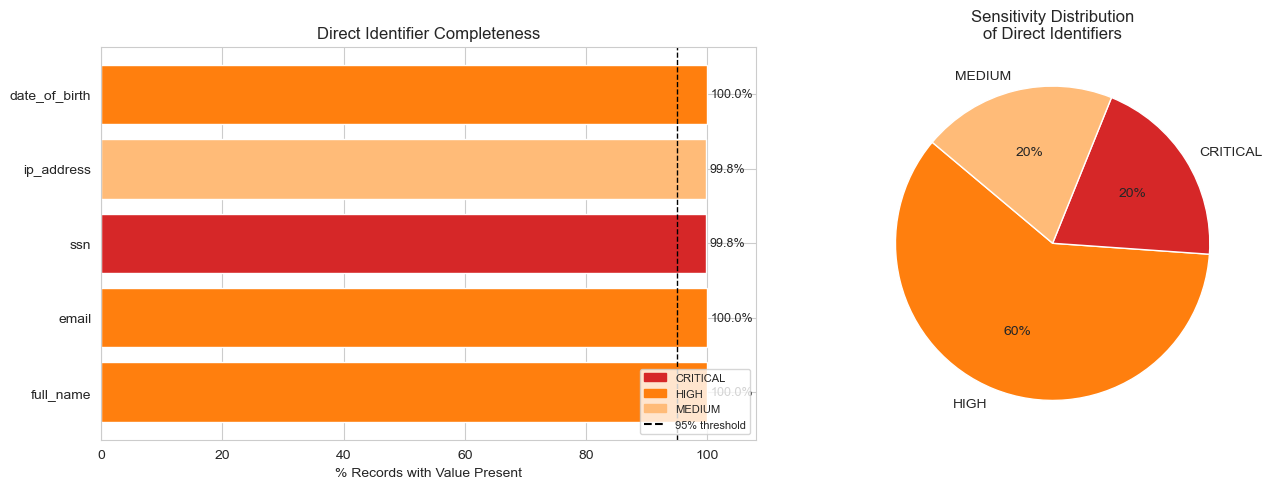

In [4]:
# ============================================================================
# VISUALISATION: Direct Identifier Completeness & Sensitivity Overview
# ============================================================================

df_results = pd.DataFrame(results)

sensitivity_color = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#ffbb78'}
colors = [sensitivity_color[meta['sensitivity']] for meta in direct_identifiers.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Completeness bar chart ---
pct_values = [float(r['% Present'].replace('%', '')) for r in results]
bars = axes[0].barh(df_results['Field'], pct_values, color=colors)
axes[0].axvline(x=95, color='black', linestyle='--', linewidth=1, label='95% threshold')
axes[0].set_xlabel('% Records with Value Present')
axes[0].set_title('Direct Identifier Completeness')
axes[0].set_xlim(0, 108)
for bar, val in zip(bars, pct_values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)

# --- Right: Sensitivity classification pie ---
sensitivity_counts = pd.Series([meta['sensitivity'] for meta in direct_identifiers.values()]).value_counts()
pie_colors = [sensitivity_color.get(s, 'grey') for s in sensitivity_counts.index]
axes[1].pie(
    sensitivity_counts.values,
    labels=sensitivity_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=140
)
axes[1].set_title('Sensitivity Distribution\nof Direct Identifiers')

legend_patches = [
    mpatches.Patch(color='#d62728', label='CRITICAL'),
    mpatches.Patch(color='#ff7f0e', label='HIGH'),
    mpatches.Patch(color='#ffbb78', label='MEDIUM'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='95% threshold'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()